**LangMem**

LangMem is a library designed to equip AI agents with long-term, persistent memory. While LangGraph's state management handles the short-term memory and workflow for a given task, LangMem provides the long-term historical context, allowing the agent to remember past interactions, user preferences, and key information across completely separate sessions.



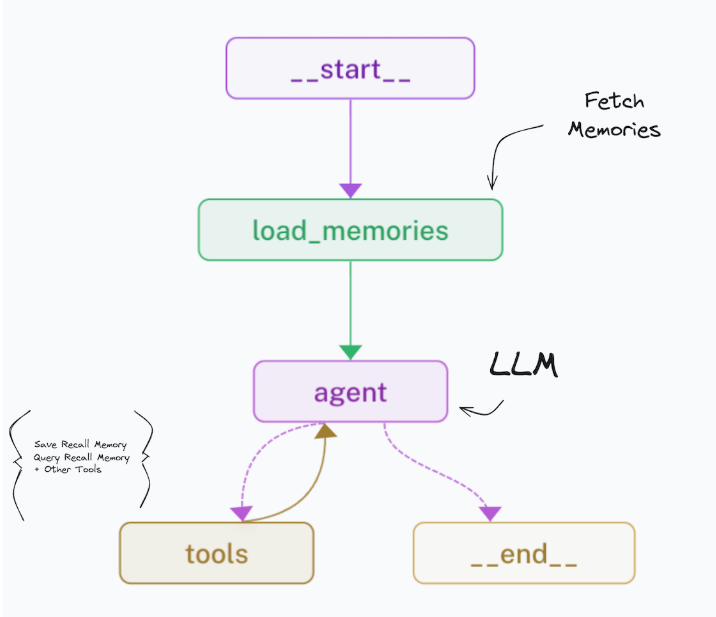

#### **Key LangMem Features**

- **Persistence**: Memories are saved to a database, so they are not lost when the application restarts. This allows an agent to pick up a conversation exactly where it left off, even days or months later.

- **Efficient Retrieval**: LangMem includes built-in indexing and search capabilities. It automatically indexes memories, allowing an agent to perform efficient semantic searches to find the most relevant past interactions when responding to a new query.

- **Scalability**: By offloading memory to a dedicated storage system, LangMem can handle a virtually unlimited amount of historical data without slowing down the agent's performance.

- **Simple API**: The library is designed for ease of use, with a straightforward API to add, get, delete, and search memories, making it simple to integrate into existing applications.

**Use Case 3 - Personalized Traven Assistant Agent Workflow**

In [ ]:
# Define each tool as its own python function. Ensure to use the @tool decorator to help LangGraph identify the function as a tool that an agent can use
from langchain_core.tools import tool

@tool
def search_flights(destination: str, origin: str, date: str) -> dict:
    """Searches for flights for a given destination, origin, and date."""
    return {
        "flight": "Flight UA456",
        "departure": "08:00 AM",
        "arrival": "11:00 AM",
        "price": 350.00,
    }

@tool
def search_hotels(destination: str, check_in_date: str, check_out_date: str) -> dict:
    """Searches for hotels in a given destination for the specified dates."""
    return {
        "hotel": "The Grand Plaza",
        "price_per_night": 150.00,
        "rating": 4.5,
    }

@tool
def book_trip(destination: Optional[str] = None, start_date: Optional[str] = None, end_date: Optional[str] = None) -> str:
    """Books a trip, including flight and hotel, to a given destination for a specified period."""

    # Check if essential arguments are missing
    if not all([destination, start_date, end_date]):
        return "I can help book a trip, but I need a destination, start date, AND end date."

    # If all arguments are present, proceed with the actual booking logic
    print(f"--- Executing Booking for {destination} from {start_date} to {end_date} ---")
    return f"Successfully booked a trip to {destination} from {start_date} to {end_date}."

# Create a list of tools that an agent can use in its workflow execution
tools = [
    search_flights,
    search_hotels,
    book_trip,
]

In [ ]:
# Define Agent State and Memory

# Set up storage
store = InMemoryStore(
    index={
        "dims": 1536,
        "embed": {
          "model": "openai:text-embedding-3-small",
          "api_key": userdata.get('OPENAI_API_KEY')
    }
    }
)

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], lambda x, y: x + y]
    # Add a field to track the human's approval decision
    human_approval: str


In [ ]:
# --- 3. Define the Agent Class ---
class ReActAgentWithMemoryAndApproval:
    def __init__(self, model, tools, checkpointer):
        self.model = model.bind_tools(tools)
        self.checkpointer = checkpointer
        self.graph = self._build_graph(tools)

    def _build_graph(self, tools):
        graph = StateGraph(AgentState)
        graph.add_node("call_model", self._call_model)
        graph.add_node("call_tool", ToolNode(tools))
        graph.add_node("human_in_the_loop", self._human_in_the_loop)

        graph.add_conditional_edges(
            "call_model",
            self._decide_next_step,
            {"human_in_the_loop": "human_in_the_loop", "call_tool": "call_tool", END: END},
        )
        graph.add_conditional_edges(
            "human_in_the_loop",
            # This edge now checks the 'human_approval' state field
            lambda state: "call_tool" if state.get("human_approval") == "yes" else END,
        )
        graph.add_edge("call_tool", "call_model")
        graph.set_entry_point("call_model")
        return graph.compile(checkpointer=self.checkpointer)

    def _call_model(self, state: AgentState) -> dict:
        messages = state["messages"]
        response = self.model.invoke(messages)
        return {"messages": [response]}

    def _decide_next_step(self, state: AgentState) -> str:
        last_message = state["messages"][-1]
        if not last_message.tool_calls:
            return END
        # Route to human for specific tools
        if last_message.tool_calls[0]["name"] == "book_trip":
            return "human_in_the_loop"
        return "call_tool"

    def _human_in_the_loop(self, state: AgentState) -> dict:
        last_message = state["messages"][-1]
        tool_call = last_message.tool_calls[0]
        print(f"\nAgent proposes to call the '{tool_call['name']}' tool with arguments: {tool_call['args']}")
        response = input("Do you approve this action? (yes/no): ").lower()
        return {"human_approval": response}

In [ ]:
# --- 4. Initialize and Run the Agent ---


# Initialize the agent

model = ChatOpenAI(model="gpt-3.5-turbo", api_key=userdata.get('OPENAI_API_KEY'), temperature=0)

# Function to run the agent with a sample query
async def run_agent_session(query):
    # Use AsyncSqliteSaver as an async context manager
    async with AsyncSqliteSaver.from_conn_string(":memory:") as checkpointer:
        # Initialize the agent INSIDE the "with" block
        travel_agent = ReActAgentWithMemoryAndApproval(model, tools, checkpointer)

        config = {"configurable": {"thread_id": "1"}}
        messages = [HumanMessage(content=query)]

        # Use the asynchronous .ainvoke() method
        result = await travel_agent.graph.ainvoke({"messages": messages}, config)

        final_response = result["messages"][-1].content
        print(f"User Query: {query}")
        print(f"Agent Response: {final_response}")


In [ ]:
# --- Example Usage ---
print("--- Session 1: Planning a trip and stating a preference ---")
await run_agent_session("I want to book a trip to Paris from NYC on October 26th for 3 nights. I prefer window seats on flights.")

print("\n" + "="*50 + "\n")

print("--- Session 2: Planning another trip (agent should recall preference) ---")
await run_agent_session("I need to book a flight and hotel for a trip to London from NYC on December 10th for 5 nights.")

--- Session 1: Planning a trip and stating a preference ---
--- Executing Booking for Paris from 2023-10-26 to 2023-10-29 ---
User Query: I want to book a trip to Paris from NYC on October 26th for 3 nights. I prefer window seats on flights.
Agent Response: I have found the following options for your trip to Paris:

- **Flight**: 
  - Flight: UA456
  - Departure: 08:00 AM
  - Arrival: 11:00 AM
  - Price: $350.0

- **Hotel**:
  - Hotel: The Grand Plaza
  - Price per night: $150.0
  - Rating: 4.5

Your trip to Paris from NYC on October 26th for 3 nights has been successfully booked.


--- Session 2: Planning another trip (agent should recall preference) ---

Agent proposes to call the 'book_trip' tool with arguments: {'destination': 'London', 'start_date': '2023-12-10', 'end_date': '2023-12-15'}
Do you approve this action? (yes/no): yes
--- Executing Booking for London from 2023-12-10 to 2023-12-15 ---
User Query: I need to book a flight and hotel for a trip to London from NYC on Decembe